<a href="https://colab.research.google.com/github/lamyaah/test/blob/main/Dynamic_env_planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Environment, Dynamic Obstacle, and Path Planning Module
This section defines the `GridEnvironment`, `DynamicObstacle` classes, and the `astar_spacetime` algorithm for path planning.

In [38]:
import numpy as np
import heapq
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


class GridEnvironment:
    def __init__(self, shape=(20, 20, 10)):
        self.shape = shape
        self.grid = np.zeros(shape, dtype=int)

    def add_obstacle_block(self, x_range, y_range, z_range):
        self.grid[x_range[0]:x_range[1],
                  y_range[0]:y_range[1],
                  z_range[0]:z_range[1]] = 1

    def is_free(self, x, y, z, t, dynamic_obstacles):
        # 1. Static boundary and obstacle check
        if not (0 <= x < self.shape[0] and
                0 <= y < self.shape[1] and
                0 <= z < self.shape[2]):
            return False
        if self.grid[x, y, z] == 1:
            return False

        # 2. Dynamic obstacle check
        for obs in dynamic_obstacles:
            if obs.position_at(t) == (x, y, z):
                return False
        return True

class DynamicObstacle:
    def __init__(self, waypoints, loop=True, name="Obs"):
        self.waypoints = waypoints
        self.loop = loop
        self.name = name

    def position_at(self, t):
        if self.loop:
            return self.waypoints[t % len(self.waypoints)]
        else:
            idx = min(t, len(self.waypoints) - 1)
            return self.waypoints[idx]

def move_cost(cur, nxt):
    dx, dy, dz = nxt[0]-cur[0], nxt[1]-cur[1], nxt[2]-cur[2]
    dist = math.sqrt(dx**2 + dy**2 + dz**2)
    # 0.5 penalty for climbing, 0 cost if waiting in place
    return dist + max(0, dz) * 0.5

def heuristic(node, goal):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(node, goal)))

def astar_spacetime(env, start, goal, dynamic_obstacles, t_max=100):
    start_state = (*start, 0) # (x, y, z, t)
    open_heap = [(0, start_state)]
    came_from = {start_state: None}
    g_score = {start_state: 0.0}

    while open_heap:
        _, current = heapq.heappop(open_heap)
        cx, cy, cz, ct = current

        if (cx, cy, cz) == goal:
            path = []
            while current:
                path.append(current[:3])
                current = came_from[current]
            return path[::-1], g_score[(*goal, ct)], ct

        if ct >= t_max:
            continue

        # 26 moves + 1 stay-in-place move
        moves = [(dx, dy, dz) for dx in [-1,0,1] for dy in [-1,0,1] for dz in [-1,0,1]]

        for dx, dy, dz in moves:
            nx, ny, nz = cx+dx, cy+dy, cz+dz
            nt = ct + 1

            if not env.is_free(nx, ny, nz, nt, dynamic_obstacles):
                continue

            cost = move_cost((cx,cy,cz), (nx,ny,nz))
            tg = g_score[current] + cost
            neighbor_state = (nx, ny, nz, nt)

            if tg < g_score.get(neighbor_state, float('inf')):
                g_score[neighbor_state] = tg
                came_from[neighbor_state] = current
                f = tg + heuristic((nx,ny,nz), goal)
                heapq.heappush(open_heap, (f, neighbor_state))

    return [], float('inf'), -1

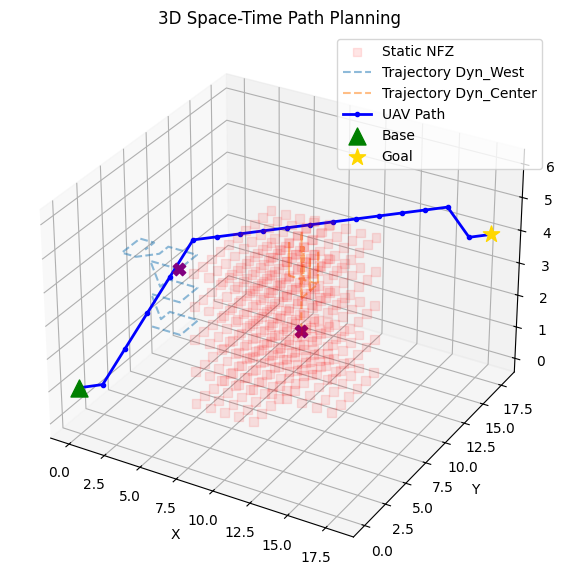

In [39]:
# --- Execution ---
# single uav
env = GridEnvironment(shape=(20, 20, 10))
env.add_obstacle_block((5, 10), (5, 15), (0, 5))
env.add_obstacle_block((12, 17), (2, 8), (2, 7))

BASE = (0, 0, 1)
TARGET = (18, 18, 4)

# Dynamic Obstacles
obs1_waypoints = [
    (2,5,2), (3,5,2), (4,5,2), (4,6,2), (4,7,2), (3,7,2), (2,7,2), (2,6,2),
    (2,5,3), (3,5,3), (4,5,3), (4,6,3), (4,7,3), (3,7,3), (2,7,3), (2,6,3),
    (2,5,4), (3,5,4), (4,5,4), (4,6,4), (4,7,4), (3,7,4), (2,7,4), (2,6,4),
    (1,5,4), (0,5,4), (0,6,4), (0,7,4), (1,7,4), (1,6,4)
]


obs2_waypoints = [
    (10,9,2), (10,9,3), (10,9,4), (10,9,5), (10,9,4), (10,9,3),
    (10,10,3), (10,10,4), (10,10,3),
    (10,11,3), (10,11,4), (10,11,3),
    (9,11,3), (9,11,4), (9,11,3),
    (8,11,3), (8,11,4), (8,11,3)
]

dynamic_obstacles = [
    DynamicObstacle(obs1_waypoints, loop=True, name="Dyn_West"),
    DynamicObstacle(obs2_waypoints, loop=True, name="Dyn_Center"),
]
path, cost, arrival_t = astar_spacetime(env, BASE, TARGET, dynamic_obstacles)

# --- Visualization ---

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Static Obstacles (NFZs)
x, y, z = np.where(env.grid == 1)
ax.scatter(x, y, z, c='red', marker='s', alpha=0.1, s=40, label='Static NFZ')

# Dynamic Obstacle Trajectories
for obs in dynamic_obstacles:
    ox, oy, oz = zip(*obs.waypoints)
    ax.plot(ox, oy, oz, '--', alpha=0.5, label=f'Trajectory {obs.name}')
    # Mark where the dynamic obstacles end up at arrival time
    if arrival_t != -1:
        px, py, pz = obs.position_at(arrival_t)
        ax.scatter([px], [py], [pz], color='purple', s=80, marker='X')

# UAV Path
if path:
    px, py, pz = zip(*path)
    ax.plot(px, py, pz, '-o', markersize=3, label='UAV Path', color='blue', linewidth=2)

ax.scatter(*BASE, c='green', s=150, marker='^', label='Base')
ax.scatter(*TARGET, c='gold', s=150, marker='*', label='Goal')

ax.set_title("3D Space-Time Path Planning")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.show()

### 2. Multi-UAV Coordination Module
This section introduces the `UAVPathObstacle` class and the `plan_multi_uav` function, which implements a prioritized planning approach for multiple UAVs.

In [40]:


class UAVPathObstacle:
    """Treats a completed UAV path as a dynamic obstacle for other UAVs."""
    def __init__(self, path, name):
        self.path = path  # List of (x, y, z)
        self.name = name

    def position_at(self, t):

        idx = min(t, len(self.path) - 1)
        return self.path[idx]



def plan_multi_uav(env, starts, goals, env_dynamic_obstacles):
    all_paths = []

    current_dynamic_obstacles = list(env_dynamic_obstacles)

    colors = ['blue', 'green', 'orange']

    for i in range(len(starts)):
        print(f"Planning for UAV {i+1}...")

        print(f"  UAV {i+1} Start: {starts[i]}")
        print(f"  UAV {i+1} Goal: {goals[i]}")
        print(f"  UAV {i+1} Current Dynamic Obstacles: {[obs.name for obs in current_dynamic_obstacles]}")

        path, cost, arrival_t = astar_spacetime(
            env, starts[i], goals[i], current_dynamic_obstacles, t_max=100
        )

        if not path:
            print(f"UAV {i+1} could not find a path!")
            continue

        all_paths.append(path)

        new_obs = UAVPathObstacle(path, name=f"UAV_{i+1}_Path")
        current_dynamic_obstacles.append(new_obs)

    return all_paths

### 3. Visualization Module (for Single UAV Scenario)

In [41]:
import sys
!{sys.executable} -m pip install moviepy imageio imageio[ffmpeg]

### 4. Visualization Module - Helper Functions
This section defines a helper function `generate_uav_animation_gif` to create 3D animations of UAV paths, dynamic obstacles, and static obstacles.

In [42]:
import matplotlib.animation as animation
import numpy as np
import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip

def generate_uav_animation_gif(env, uav_paths_list, env_dynamic_obstacles, starts_list, goals_list, uav_colors, title, filename):
    t_max = 30 # Define t_max for animation, consistent with planning

    all_extended_uav_paths = []
    for i_uav, (path_uav, goal_uav) in enumerate(zip(uav_paths_list, goals_list)):
        extended_path = list(path_uav)
        while len(extended_path) <= t_max:
            extended_path.append(goal_uav)
        all_extended_uav_paths.append(extended_path)

    max_animation_frames = t_max + 1


    fig_anim = plt.figure(figsize=(12, 8))
    ax_anim = fig_anim.add_subplot(111, projection='3d')

    x_static, y_static, z_static = np.where(env.grid == 1)
    ax_anim.scatter(x_static, y_static, z_static, c='red', marker='s', alpha=0.1, s=40, label='Static NFZ')

    for obs in env_dynamic_obstacles:
        ox, oy, oz = zip(*obs.waypoints)
        ax_anim.plot(ox, oy, oz, ':', color='gray', alpha=0.7, label=f'Trajectory {obs.name}')


    uav_dots = []
    uav_lines = []

    for i, path_uav in enumerate(all_extended_uav_paths):
        color = uav_colors[i % len(uav_colors)]
        dot, = ax_anim.plot([], [], [], 'o', markersize=8, color=color, label=f'UAV {i+1}')
        line, = ax_anim.plot([], [], [], '-.', color=color, linewidth=1)
        uav_dots.append(dot)
        uav_lines.append(line)

        ax_anim.scatter(*starts_list[i], c=color, s=150, marker='^')
        ax_anim.scatter(*goals_list[i], c=color, s=150, marker='*')

    dyn_obs_dots = []
    for i, obs in enumerate(env_dynamic_obstacles):
        dot, = ax_anim.plot([], [], [], 'X', markersize=10, color='purple', label=f'Dynamic Obs {i+1}')
        dyn_obs_dots.append(dot)

    ax_anim.set_xlim([0, env.shape[0]])
    ax_anim.set_ylim([0, env.shape[1]])
    ax_anim.set_zlim([0, env.shape[2]])
    ax_anim.set_xlabel('X')
    ax_anim.set_ylabel('Y')
    ax_anim.set_zlabel('Z')
    ax_anim.set_title(title)
    ax_anim.legend()

    def update(frame):
        artists = []

        for i, path_uav_extended in enumerate(all_extended_uav_paths):
            current_uav_pos = path_uav_extended[frame]
            uav_dots[i].set_data([current_uav_pos[0]], [current_uav_pos[1]])
            uav_dots[i].set_3d_properties([current_uav_pos[2]])
            artists.append(uav_dots[i])

            uav_lines[i].set_data([p[0] for p in path_uav_extended[:frame+1]], [p[1] for p in path_uav_extended[:frame+1]])
            uav_lines[i].set_3d_properties([p[2] for p in path_uav_extended[:frame+1]])
            artists.append(uav_lines[i])

        for i, obs in enumerate(env_dynamic_obstacles):
            obs_pos = obs.position_at(frame)
            dyn_obs_dots[i].set_data([obs_pos[0]], [obs_pos[1]])
            dyn_obs_dots[i].set_3d_properties([obs_pos[2]])
            artists.append(dyn_obs_dots[i])

        fig_anim.suptitle(f'{title} - Time: {frame}', fontsize=16)
        return artists

    anim = animation.FuncAnimation(fig_anim, update, frames=range(max_animation_frames),
                                   interval=200, blit=True)


    gif_filename = filename
    print(f"Saving animation as '{gif_filename}'...")
    anim.save(gif_filename, writer='pillow', fps=10)
    print(f"Animation '{gif_filename}' saved!")

    plt.close(fig_anim)
    mp4_filename = filename.replace('.gif', '.mp4')
    print(f"Converting '{gif_filename}' to '{mp4_filename}'...")
    try:
        clip = VideoFileClip(gif_filename)
        clip.write_videofile(mp4_filename, codec='libx264', audio_codec='aac')
        print(f"Successfully converted '{gif_filename}' to '{mp4_filename}'!")
    except Exception as e:
        print(f"Error converting GIF to MP4: {e}")

### Generate GIF/MP4 for Single UAV Scenario

In [43]:


if path:
    generate_uav_animation_gif(
        env=env,
        uav_paths_list=[path],
        env_dynamic_obstacles=dynamic_obstacles,
        starts_list=[BASE],
        goals_list=[TARGET],
        uav_colors=['blue'],
        title='Single UAV Path Planning',
        filename='single_uav_simulation.gif'
    )
else:
    print("No path found for single UAV scenario.")

Saving animation as 'single_uav_simulation.gif'...
Animation 'single_uav_simulation.gif' saved!
Converting 'single_uav_simulation.gif' to 'single_uav_simulation.mp4'...
Moviepy - Building video single_uav_simulation.mp4.
Moviepy - Writing video single_uav_simulation.mp4



Moviepy - Done !
Moviepy - video ready single_uav_simulation.mp4
Successfully converted 'single_uav_simulation.gif' to 'single_uav_simulation.mp4'!


### 5. Visualization Module (for Multi-UAV Scenario)
This section executes the multi-UAV planning and uses the visualization helper function to generate an animation for the coordinated UAV paths.

### Generate GIF/MP4 for Multi-UAV Scenario

In [44]:


env_multi_uav = GridEnvironment(shape=(20, 20, 10))
env_multi_uav.add_obstacle_block((5, 10), (5, 15), (0, 5)) # Static NFZ
obs1_waypoints_multi = [
    (2,5,2), (3,5,2), (4,5,2), (4,6,2), (4,7,2), (3,7,2), (2,7,2), (2,6,2), # Original loop
    (2,5,3), (3,5,3), (4,5,3), (4,6,3), (4,7,3), (3,7,3), (2,7,3), (2,6,3), # Same loop, higher Z
    (2,5,4), (3,5,4), (4,5,4), (4,6,4), (4,7,4), (3,7,4), (2,7,4), (2,6,4), # Same loop, even higher Z
    (1,5,4), (0,5,4), (0,6,4), (0,7,4), (1,7,4), (1,6,4) # Extended movement towards (0,y,z)
]

obs2_waypoints_multi = [
    (10,9,2), (10,9,3), (10,9,4), (10,9,5), (10,9,4), (10,9,3),
    (10,10,3), (10,10,4), (10,10,3),
    (10,11,3), (10,11,4), (10,11,3),
    (9,11,3), (9,11,4), (9,11,3),
    (8,11,3), (8,11,4), (8,11,3)
]

env_hazards_multi = [
    DynamicObstacle(obs1_waypoints_multi, loop=True, name="Dyn_West"),
    DynamicObstacle(obs2_waypoints_multi, loop=True, name="Dyn_Center"),
]

starts_multi = [(0, 0, 1), (0, 2, 1), (2, 0, 1)]
goals_multi  = [(18, 18, 4), (15, 3, 6), (5, 18, 8)]

uav_results_multi = plan_multi_uav(env_multi_uav, starts_multi, goals_multi, env_hazards_multi)

if uav_results_multi:
    generate_uav_animation_gif(
        env=env_multi_uav,
        uav_paths_list=uav_results_multi,
        env_dynamic_obstacles=env_hazards_multi,
        starts_list=starts_multi,
        goals_list=goals_multi,
        uav_colors=['royalblue', 'limegreen', 'darkorange'],
        title='Multi-UAV Path Planning (Prioritized A*)',
        filename='multi_uav_simulation.gif'
    )
else:
    print("No paths found for multi-UAV scenario.")

Planning for UAV 1...
  UAV 1 Start: (0, 0, 1)
  UAV 1 Goal: (18, 18, 4)
  UAV 1 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center']
Planning for UAV 2...
  UAV 2 Start: (0, 2, 1)
  UAV 2 Goal: (15, 3, 6)
  UAV 2 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path']
Planning for UAV 3...
  UAV 3 Start: (2, 0, 1)
  UAV 3 Goal: (5, 18, 8)
  UAV 3 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path', 'UAV_2_Path']
Saving animation as 'multi_uav_simulation.gif'...
Animation 'multi_uav_simulation.gif' saved!
Converting 'multi_uav_simulation.gif' to 'multi_uav_simulation.mp4'...
Moviepy - Building video multi_uav_simulation.mp4.
Moviepy - Writing video multi_uav_simulation.mp4



Moviepy - Done !
Moviepy - video ready multi_uav_simulation.mp4
Successfully converted 'multi_uav_simulation.gif' to 'multi_uav_simulation.mp4'!


### metrics: time, cost, path length, success rate

In [45]:
print('--- Single UAV Metrics ---')
if path:
    print(f"UAV Path Found: Yes")
    print(f"Arrival Time: {arrival_t} timesteps")
    print(f"Total Cost: {cost:.2f}")
    print(f"Path Length (nodes): {len(path)}")
else:
    print(f"UAV Path Found: No")

--- Single UAV Metrics ---
UAV Path Found: Yes
Arrival Time: 18 timesteps
Total Cost: 29.05
Path Length (nodes): 19


### Metrics for Multi-UAV Scenario

In [46]:
print('\n--- Multi-UAV Metrics ---')

success_count_multi = 0
for i, uav_path in enumerate(uav_results_multi):
    if uav_path:
        success_count_multi += 1

        temp_dynamic_obstacles = list(env_hazards_multi)
        for j in range(i):
            temp_dynamic_obstacles.append(UAVPathObstacle(uav_results_multi[j], name=f"UAV_{j+1}_Path"))

        _, uav_cost, uav_arrival_t = astar_spacetime(env_multi_uav, starts_multi[i], goals_multi[i], temp_dynamic_obstacles, t_max=100)

        print(f"UAV {i+1} Path Found: Yes")
        print(f"  Arrival Time: {uav_arrival_t} timesteps")
        print(f"  Total Cost: {uav_cost:.2f}")
        print(f"  Path Length (nodes): {len(uav_path)}")
    else:
        print(f"UAV {i+1} Path Found: No")

print(f"\nMulti-UAV Success Rate: {success_count_multi}/{len(starts_multi)} ({(success_count_multi / len(starts_multi)) * 100:.2f}%) ")


--- Multi-UAV Metrics ---
UAV 1 Path Found: Yes
  Arrival Time: 18 timesteps
  Total Cost: 29.05
  Path Length (nodes): 19
UAV 2 Path Found: Yes
  Arrival Time: 15 timesteps
  Total Cost: 19.89
  Path Length (nodes): 16
UAV 3 Path Found: Yes
  Arrival Time: 18 timesteps
  Total Cost: 25.35
  Path Length (nodes): 19

Multi-UAV Success Rate: 3/3 (100.00%) 


My Code

In [47]:
import sys
!{sys.executable} -m pip install ortools

In [48]:
import time
import math
import heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from moviepy.editor import VideoFileClip
from ortools.sat.python import cp_model

In [49]:
def path_cost(path):
    if not path:
        return float("inf")
    return sum(move_cost(path[t], path[t+1]) for t in range(len(path)-1))


def extend_path(path, horizon):
    path = list(path)
    while len(path) <= horizon:
        path.append(path[-1])
    return path[:horizon+1]


def paths_conflict(path_a, path_b, horizon):
    a = extend_path(path_a, horizon)
    b = extend_path(path_b, horizon)

    for t in range(horizon + 1):
        # same-cell collision
        if a[t] == b[t]:
            return True

    for t in range(horizon):
        # edge-swap collision
        if a[t] == b[t+1] and a[t+1] == b[t]:
            return True

    return False


def near_miss_count(paths, horizon, threshold=1.5):
    extended = [extend_path(p, horizon) for p in paths]
    count = 0

    for t in range(horizon + 1):
        for i in range(len(extended)):
            for j in range(i + 1, len(extended)):
                a = extended[i][t]
                b = extended[j][t]
                d = math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)
                if d <= threshold:
                    count += 1

    return count

In [50]:
def astar_spacetime_with_penalty(
    env,
    start,
    goal,
    dynamic_obstacles,
    penalty_cells=None,
    penalty_weight=3.0,
    t_max=100
):
    if penalty_cells is None:
        penalty_cells = set()

    start_state = (*start, 0)
    open_heap = [(0, start_state)]
    came_from = {start_state: None}
    g_score = {start_state: 0.0}

    while open_heap:
        _, current = heapq.heappop(open_heap)
        cx, cy, cz, ct = current

        if (cx, cy, cz) == goal:
            path = []
            while current:
                path.append(current[:3])
                current = came_from[current]
            return path[::-1], g_score[(*goal, ct)], ct

        if ct >= t_max:
            continue

        moves = [
            (dx, dy, dz)
            for dx in [-1, 0, 1]
            for dy in [-1, 0, 1]
            for dz in [-1, 0, 1]
        ]

        for dx, dy, dz in moves:
            nx, ny, nz = cx + dx, cy + dy, cz + dz
            nt = ct + 1

            if not env.is_free(nx, ny, nz, nt, dynamic_obstacles):
                continue

            nxt = (nx, ny, nz)
            base_cost = move_cost((cx, cy, cz), nxt)

            penalty = 0
            if nxt in penalty_cells:
                penalty += penalty_weight

            tg = g_score[current] + base_cost + penalty
            neighbor_state = (nx, ny, nz, nt)

            if tg < g_score.get(neighbor_state, float("inf")):
                g_score[neighbor_state] = tg
                came_from[neighbor_state] = current
                f = tg + heuristic(nxt, goal)
                heapq.heappush(open_heap, (f, neighbor_state))

    return [], float("inf"), -1


def generate_candidate_paths(
    env,
    start,
    goal,
    dynamic_obstacles,
    num_candidates=12,
    t_max=100
):
    candidates = []
    seen = set()

    penalty_sets = [set()]

    for k in range(num_candidates):
        penalty_cells = penalty_sets[k] if k < len(penalty_sets) else set()

        path, cost, arrival_t = astar_spacetime_with_penalty(
            env,
            start,
            goal,
            dynamic_obstacles,
            penalty_cells=penalty_cells,
            penalty_weight=3.0 + k,
            t_max=t_max
        )

        if not path:
            continue

        path_tuple = tuple(path)
        if path_tuple not in seen:
            seen.add(path_tuple)
            candidates.append({
                "path": path,
                "cost": path_cost(path),
                "arrival": len(path) - 1
            })

            # Create new penalty sets from this path to encourage alternatives
            middle_cells = path[1:-1]
            for step in range(2, max(3, len(middle_cells)//4)):
                penalty_sets.append(set(middle_cells[::step]))

            penalty_sets.append(set(middle_cells))

    return candidates

In [51]:
def csp_select_multi_uav_paths(
    env,
    starts,
    goals,
    dynamic_obstacles,
    num_candidates=15,
    t_max_astar=100,
    alpha_travel=100,
    beta_makespan=10,
    time_limit_seconds=60
):
    print("Generating candidate paths...")

    all_candidates = []

    for i in range(len(starts)):
        candidates = generate_candidate_paths(
            env=env,
            start=starts[i],
            goal=goals[i],
            dynamic_obstacles=dynamic_obstacles,
            num_candidates=num_candidates,
            t_max=t_max_astar
        )

        print(f"UAV {i+1}: {len(candidates)} candidate paths")

        if not candidates:
            print(f"No candidate paths found for UAV {i+1}")
            return [], {}

        all_candidates.append(candidates)

    horizon = max(
        max(c["arrival"] for c in candidates)
        for candidates in all_candidates
    )

    print(f"CSP horizon: {horizon}")

    model = cp_model.CpModel()
    n_uavs = len(starts)

    # Variable:
    # choice[i] = selected candidate path index for UAV i
    choice = []
    for i in range(n_uavs):
        choice.append(
            model.NewIntVar(0, len(all_candidates[i]) - 1, f"choice_uav_{i}")
        )

    # Forbid conflicting candidate combinations
    for i in range(n_uavs):
        for j in range(i + 1, n_uavs):
            for pi, cand_i in enumerate(all_candidates[i]):
                for pj, cand_j in enumerate(all_candidates[j]):
                    if paths_conflict(cand_i["path"], cand_j["path"], horizon):
                        model.AddForbiddenAssignments(
                            [choice[i], choice[j]],
                            [(pi, pj)]
                        )

    # Cost and arrival variables
    selected_cost = []
    selected_arrival = []

    for i in range(n_uavs):
        costs = [int(round(c["cost"] * 100)) for c in all_candidates[i]]
        arrivals = [c["arrival"] for c in all_candidates[i]]

        cost_var = model.NewIntVar(0, max(costs), f"cost_uav_{i}")
        arrival_var = model.NewIntVar(0, max(arrivals), f"arrival_uav_{i}")

        model.AddElement(choice[i], costs, cost_var)
        model.AddElement(choice[i], arrivals, arrival_var)

        selected_cost.append(cost_var)
        selected_arrival.append(arrival_var)

    total_cost = model.NewIntVar(0, 10_000_000, "total_cost")
    model.Add(total_cost == sum(selected_cost))

    makespan = model.NewIntVar(0, horizon, "makespan")
    model.AddMaxEquality(makespan, selected_arrival)

    model.Minimize(alpha_travel * total_cost + beta_makespan * makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_seconds
    solver.parameters.num_search_workers = 8

    t0 = time.time()
    status = solver.Solve(model)
    runtime = time.time() - t0

    if status not in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        print("No CSP solution found.")
        print("Try increasing num_candidates.")
        print("Solver status:", solver.StatusName(status))
        return [], {}

    selected_paths = []

    print("\n--- CSP Path Selection Results ---")
    print("Status:", solver.StatusName(status))
    print(f"Runtime: {runtime:.3f} seconds")
    print(f"Total cost: {solver.Value(total_cost) / 100:.2f}")
    print(f"Makespan: {solver.Value(makespan)}")

    for i in range(n_uavs):
        selected_idx = solver.Value(choice[i])
        selected = all_candidates[i][selected_idx]
        selected_paths.append(selected["path"])

        print(f"\nUAV {i+1}")
        print(f"  Selected candidate: {selected_idx}")
        print(f"  Path length: {len(selected['path'])}")
        print(f"  Arrival time: {selected['arrival']}")
        print(f"  Cost: {selected['cost']:.2f}")

    metrics = {
        "runtime": runtime,
        "total_cost": solver.Value(total_cost) / 100,
        "makespan": solver.Value(makespan),
        "path_costs": [path_cost(p) for p in selected_paths],
        "path_lengths": [len(p) for p in selected_paths],
        "near_miss_count": near_miss_count(selected_paths, horizon),
        "horizon": horizon
    }

    print(f"\nNear-miss count: {metrics['near_miss_count']}")

    return selected_paths, metrics

In [52]:
# Reuse the same objects from your notebook:
# env_multi_uav
# starts_multi
# goals_multi
# env_hazards_multi

env_multi_uav_csp = GridEnvironment(shape=(20, 20, 10))
env_multi_uav_csp.add_obstacle_block((5, 10), (5, 15), (0, 5))

obs1_waypoints_multi = [
    (2,5,2), (3,5,2), (4,5,2), (4,6,2), (4,7,2), (3,7,2), (2,7,2), (2,6,2),
    (2,5,3), (3,5,3), (4,5,3), (4,6,3), (4,7,3), (3,7,3), (2,7,3), (2,6,3),
    (2,5,4), (3,5,4), (4,5,4), (4,6,4), (4,7,4), (3,7,4), (2,7,4), (2,6,4),
    (1,5,4), (0,5,4), (0,6,4), (0,7,4), (1,7,4), (1,6,4)
]

obs2_waypoints_multi = [
    (10,9,2), (10,9,3), (10,9,4), (10,9,5), (10,9,4), (10,9,3),
    (10,10,3), (10,10,4), (10,10,3),
    (10,11,3), (10,11,4), (10,11,3),
    (9,11,3), (9,11,4), (9,11,3),
    (8,11,3), (8,11,4), (8,11,3)
]

env_hazards_multi_csp = [
    DynamicObstacle(obs1_waypoints_multi, loop=True, name="Dyn_West"),
    DynamicObstacle(obs2_waypoints_multi, loop=True, name="Dyn_Center"),
]

starts_multi_csp = [(0, 0, 1), (0, 2, 1), (2, 0, 1)]
goals_multi_csp  = [(18, 18, 4), (15, 3, 6), (5, 18, 8)]

csp_paths_multi, csp_metrics_multi = csp_select_multi_uav_paths(
    env=env_multi_uav,
    starts=starts_multi,
    goals=goals_multi,
    dynamic_obstacles=env_hazards_multi,
    num_candidates=20,
    t_max_astar=100,
    alpha_travel=100,
    beta_makespan=10,
    time_limit_seconds=60
)

Generating candidate paths...
UAV 1: 4 candidate paths
UAV 2: 7 candidate paths
UAV 3: 2 candidate paths
CSP horizon: 19

--- CSP Path Selection Results ---
Status: OPTIMAL
Runtime: 0.012 seconds
Total cost: 74.29
Makespan: 18

UAV 1
  Selected candidate: 3
  Path length: 19
  Arrival time: 18
  Cost: 29.05

UAV 2
  Selected candidate: 0
  Path length: 16
  Arrival time: 15
  Cost: 19.89

UAV 3
  Selected candidate: 1
  Path length: 19
  Arrival time: 18
  Cost: 25.35

Near-miss count: 7


In [53]:
def generate_csp_uav_animation_gif(
    env,
    uav_paths_list,
    env_dynamic_obstacles,
    starts_list,
    goals_list,
    uav_colors,
    title,
    filename
):
    t_max = max(len(p) for p in uav_paths_list) - 1

    all_extended_uav_paths = []
    for path_uav, goal_uav in zip(uav_paths_list, goals_list):
        extended_path = list(path_uav)
        while len(extended_path) <= t_max:
            extended_path.append(goal_uav)
        all_extended_uav_paths.append(extended_path)

    fig_anim = plt.figure(figsize=(12, 8))
    ax_anim = fig_anim.add_subplot(111, projection="3d")

    x_static, y_static, z_static = np.where(env.grid == 1)
    ax_anim.scatter(
        x_static, y_static, z_static,
        c="red", marker="s", alpha=0.1, s=40,
        label="Static NFZ"
    )

    for obs in env_dynamic_obstacles:
        ox, oy, oz = zip(*obs.waypoints)
        ax_anim.plot(
            ox, oy, oz,
            ":", color="gray", alpha=0.7,
            label=f"Trajectory {obs.name}"
        )

    uav_dots = []
    uav_lines = []

    for i, path_uav in enumerate(all_extended_uav_paths):
        color = uav_colors[i % len(uav_colors)]

        dot, = ax_anim.plot(
            [], [], [], "o",
            markersize=8,
            color=color,
            label=f"UAV {i+1}"
        )

        line, = ax_anim.plot(
            [], [], [], "-.",
            color=color,
            linewidth=1
        )

        uav_dots.append(dot)
        uav_lines.append(line)

        ax_anim.scatter(*starts_list[i], c=color, s=150, marker="^")
        ax_anim.scatter(*goals_list[i], c=color, s=150, marker="*")

    dyn_obs_dots = []
    for i, obs in enumerate(env_dynamic_obstacles):
        dot, = ax_anim.plot(
            [], [], [], "X",
            markersize=10,
            color="purple",
            label=f"Dynamic Obs {i+1}"
        )
        dyn_obs_dots.append(dot)

    ax_anim.set_xlim([0, env.shape[0]])
    ax_anim.set_ylim([0, env.shape[1]])
    ax_anim.set_zlim([0, env.shape[2]])
    ax_anim.set_xlabel("X")
    ax_anim.set_ylabel("Y")
    ax_anim.set_zlabel("Z")
    ax_anim.set_title(title)
    ax_anim.legend()

    def update(frame):
        artists = []

        for i, path_uav_extended in enumerate(all_extended_uav_paths):
            current_uav_pos = path_uav_extended[frame]

            uav_dots[i].set_data([current_uav_pos[0]], [current_uav_pos[1]])
            uav_dots[i].set_3d_properties([current_uav_pos[2]])
            artists.append(uav_dots[i])

            uav_lines[i].set_data(
                [p[0] for p in path_uav_extended[:frame+1]],
                [p[1] for p in path_uav_extended[:frame+1]]
            )
            uav_lines[i].set_3d_properties(
                [p[2] for p in path_uav_extended[:frame+1]]
            )
            artists.append(uav_lines[i])

        for i, obs in enumerate(env_dynamic_obstacles):
            obs_pos = obs.position_at(frame)
            dyn_obs_dots[i].set_data([obs_pos[0]], [obs_pos[1]])
            dyn_obs_dots[i].set_3d_properties([obs_pos[2]])
            artists.append(dyn_obs_dots[i])

        fig_anim.suptitle(f"{title} - Time: {frame}", fontsize=16)
        return artists

    anim = animation.FuncAnimation(
        fig_anim,
        update,
        frames=range(t_max + 1),
        interval=200,
        blit=True
    )

    print(f"Saving animation as {filename}...")
    anim.save(filename, writer="pillow", fps=10)
    print(f"Saved {filename}")

    plt.close(fig_anim)

    mp4_filename = filename.replace(".gif", ".mp4")
    print(f"Converting {filename} to {mp4_filename}...")

    try:
        clip = VideoFileClip(filename)
        clip.write_videofile(mp4_filename, codec="libx264", audio_codec="aac")
        print(f"Saved {mp4_filename}")
    except Exception as e:
        print("MP4 conversion failed:", e)

In [54]:
if csp_paths_multi:
    generate_csp_uav_animation_gif(
        env=env_multi_uav,
        uav_paths_list=csp_paths_multi,
        env_dynamic_obstacles=env_hazards_multi,
        starts_list=starts_multi,
        goals_list=goals_multi,
        uav_colors=["royalblue", "limegreen", "darkorange"],
        title="Multi-UAV Path Planning - CSP Path Selection",
        filename="multi_uav_csp_simulation.gif"
    )
else:
    print("No CSP paths available for visualization.")

Saving animation as multi_uav_csp_simulation.gif...
Saved multi_uav_csp_simulation.gif
Converting multi_uav_csp_simulation.gif to multi_uav_csp_simulation.mp4...
Moviepy - Building video multi_uav_csp_simulation.mp4.
Moviepy - Writing video multi_uav_csp_simulation.mp4



Moviepy - Done !
Moviepy - video ready multi_uav_csp_simulation.mp4
Saved multi_uav_csp_simulation.mp4


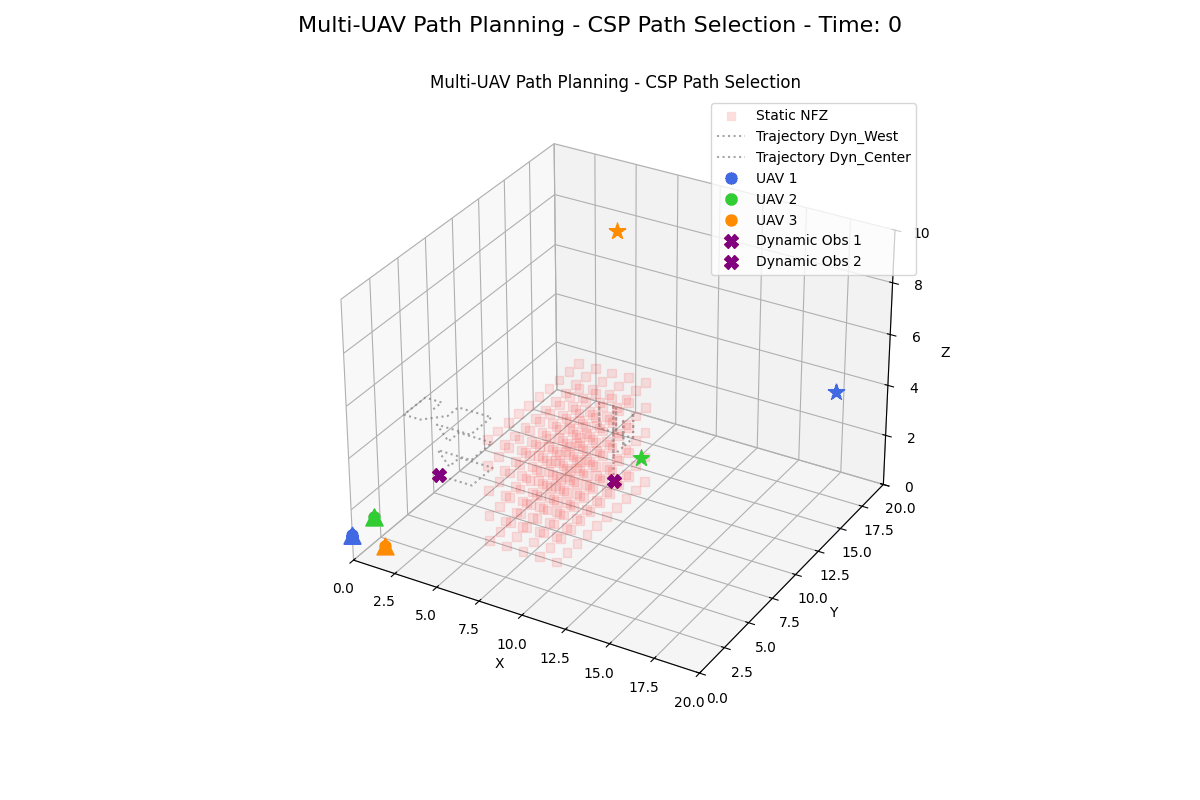

In [55]:
from IPython.display import Image

Image(filename="multi_uav_csp_simulation.gif")

In [56]:
import time
import pandas as pd

def summarize_paths(method_name, paths, runtime=None):
    costs = [path_cost(p) for p in paths]
    lengths = [len(p) for p in paths]
    arrivals = [len(p) - 1 for p in paths]
    horizon = max(arrivals)

    return {
        "Method": method_name,
        "Total Cost": round(sum(costs), 2),
        "Makespan": max(arrivals),
        "Average Path Cost": round(sum(costs) / len(costs), 2),
        "Path Lengths": lengths,
        "Arrival Times": arrivals,
        "Near Miss Count": near_miss_count(paths, horizon),
        "Runtime (s)": runtime
    }

In [57]:
start_time = time.time()

astar_paths_multi = plan_multi_uav(
    env_multi_uav,
    starts_multi,
    goals_multi,
    env_hazards_multi
)

astar_runtime = time.time() - start_time

Planning for UAV 1...
  UAV 1 Start: (0, 0, 1)
  UAV 1 Goal: (18, 18, 4)
  UAV 1 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center']
Planning for UAV 2...
  UAV 2 Start: (0, 2, 1)
  UAV 2 Goal: (15, 3, 6)
  UAV 2 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path']
Planning for UAV 3...
  UAV 3 Start: (2, 0, 1)
  UAV 3 Goal: (5, 18, 8)
  UAV 3 Current Dynamic Obstacles: ['Dyn_West', 'Dyn_Center', 'UAV_1_Path', 'UAV_2_Path']


In [58]:
comparison_results = [
    summarize_paths("Prioritized A*", astar_paths_multi, astar_runtime),
    summarize_paths("CSP / CP-SAT", csp_paths_multi, csp_metrics_multi["runtime"])
]

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Method,Total Cost,Makespan,Average Path Cost,Path Lengths,Arrival Times,Near Miss Count,Runtime (s)
0,Prioritized A*,74.29,18,24.76,"[19, 16, 19]","[18, 15, 18]",6,21.860124
1,CSP / CP-SAT,74.29,18,24.76,"[19, 16, 19]","[18, 15, 18]",7,0.011578


In [59]:
print(comparison_df.to_string(index=False))

        Method  Total Cost  Makespan  Average Path Cost Path Lengths Arrival Times  Near Miss Count  Runtime (s)
Prioritized A*       74.29        18              24.76 [19, 16, 19]  [18, 15, 18]                6    21.860124
  CSP / CP-SAT       74.29        18              24.76 [19, 16, 19]  [18, 15, 18]                7     0.011578


In [60]:
generate_uav_animation_gif(
    env=env_multi_uav,
    uav_paths_list=astar_paths_multi,
    env_dynamic_obstacles=env_hazards_multi,
    starts_list=starts_multi,
    goals_list=goals_multi,
    uav_colors=["royalblue", "limegreen", "darkorange"],
    title="Multi-UAV Path Planning - Prioritized A*",
    filename="multi_uav_astar_simulation.gif"
)

Saving animation as 'multi_uav_astar_simulation.gif'...
Animation 'multi_uav_astar_simulation.gif' saved!
Converting 'multi_uav_astar_simulation.gif' to 'multi_uav_astar_simulation.mp4'...
Moviepy - Building video multi_uav_astar_simulation.mp4.
Moviepy - Writing video multi_uav_astar_simulation.mp4



Moviepy - Done !
Moviepy - video ready multi_uav_astar_simulation.mp4
Successfully converted 'multi_uav_astar_simulation.gif' to 'multi_uav_astar_simulation.mp4'!


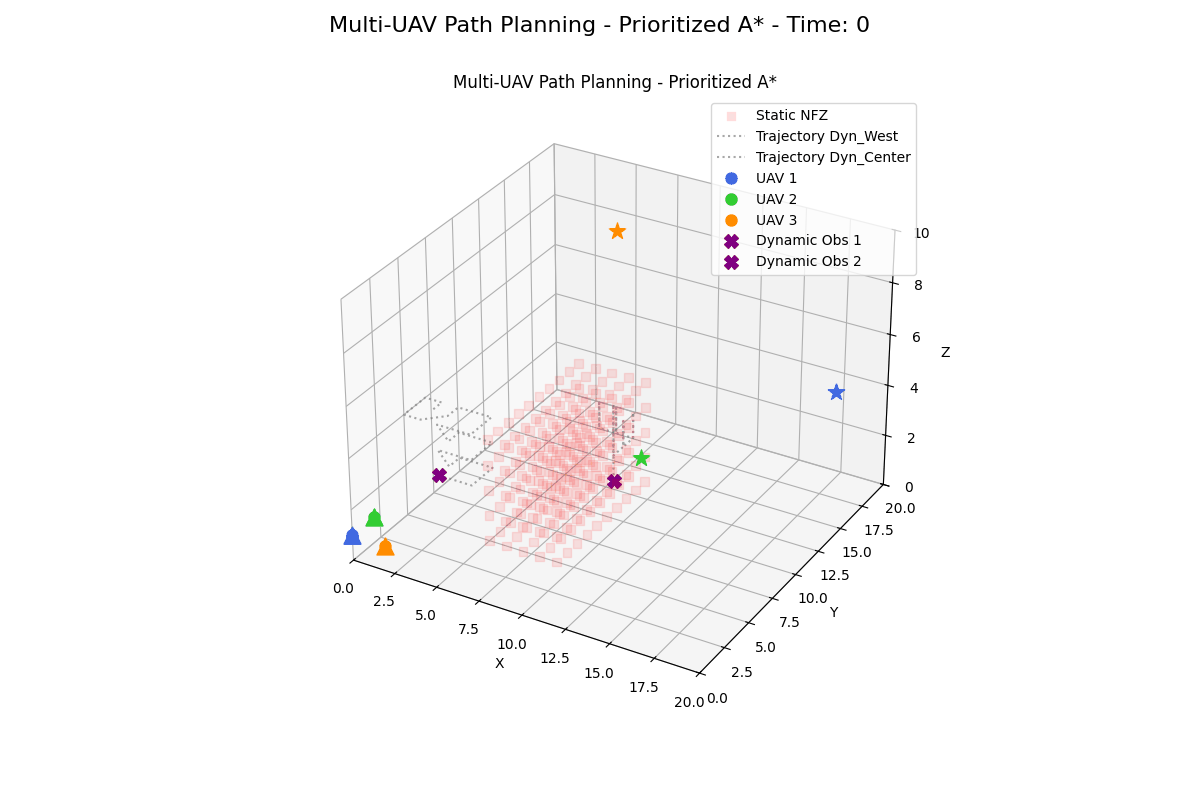

In [61]:
Image(filename="multi_uav_astar_simulation.gif")


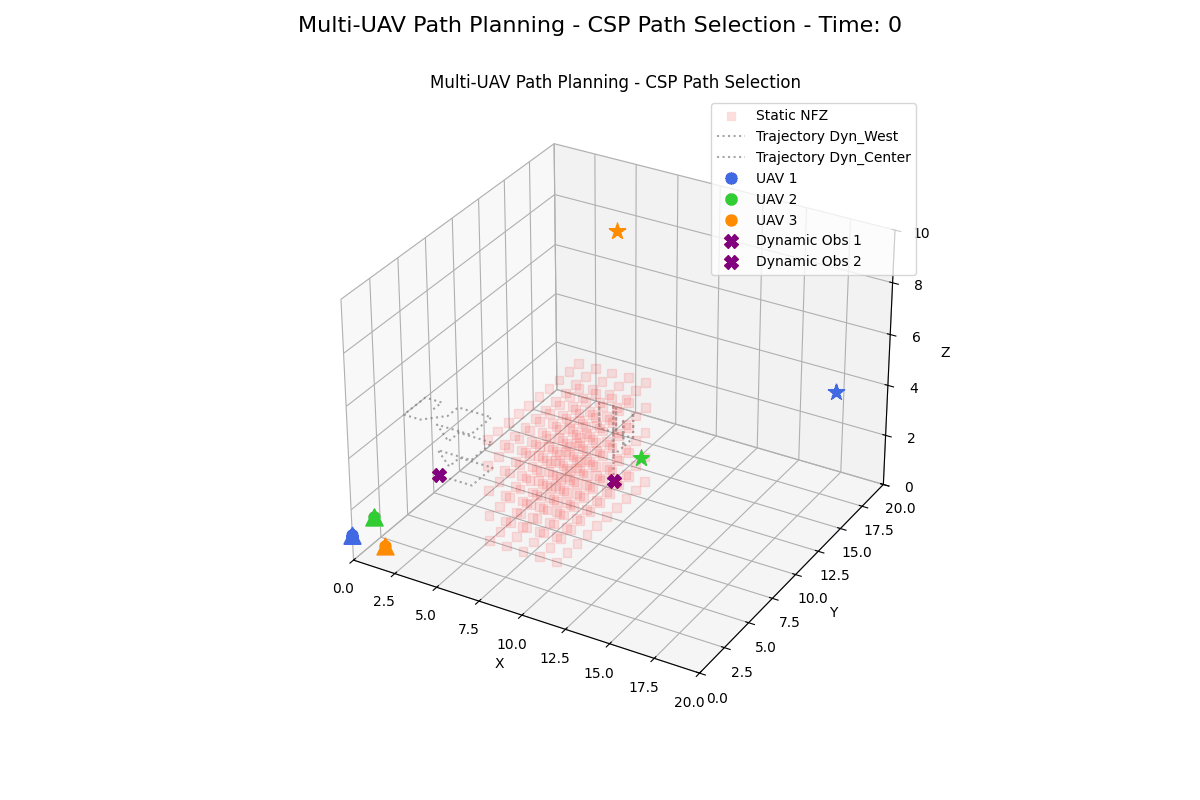

In [62]:
Image(filename="multi_uav_csp_simulation.gif")

In [63]:
astar_paths_multi
csp_paths_multi
env_hazards_multi

In [64]:
import pandas as pd


def extend_path_to_horizon(path, horizon):
    path = list(path)
    while len(path) <= horizon:
        path.append(path[-1])
    return path[:horizon + 1]


def create_position_table(method_name, uav_paths, dynamic_obstacles):
    horizon = max(len(p) for p in uav_paths) - 1
    extended_paths = [extend_path_to_horizon(p, horizon) for p in uav_paths]

    rows = []

    for t in range(horizon + 1):
        row = {
            "Method": method_name,
            "Time": t
        }

        for i, path in enumerate(extended_paths):
            x, y, z = path[t]
            row[f"UAV{i+1}_X"] = x
            row[f"UAV{i+1}_Y"] = y
            row[f"UAV{i+1}_Z"] = z
            row[f"UAV{i+1}_XYZ"] = str((x, y, z))

        for j, obs in enumerate(dynamic_obstacles):
            ox, oy, oz = obs.position_at(t)
            row[f"DynObs{j+1}_X"] = ox
            row[f"DynObs{j+1}_Y"] = oy
            row[f"DynObs{j+1}_Z"] = oz
            row[f"DynObs{j+1}_XYZ"] = str((ox, oy, oz))

        rows.append(row)

    return pd.DataFrame(rows)


astar_positions_df = create_position_table(
    method_name="Prioritized A*",
    uav_paths=astar_paths_multi,
    dynamic_obstacles=env_hazards_multi
)

csp_positions_df = create_position_table(
    method_name="CSP / CP-SAT",
    uav_paths=csp_paths_multi,
    dynamic_obstacles=env_hazards_multi
)

all_positions_df = pd.concat(
    [astar_positions_df, csp_positions_df],
    ignore_index=True
)

all_positions_df

,Method,Time,UAV1_X,UAV1_Y,UAV1_Z,UAV1_XYZ,UAV2_X,UAV2_Y,UAV2_Z,UAV2_XYZ,...,UAV3_Z,UAV3_XYZ,DynObs1_X,DynObs1_Y,DynObs1_Z,DynObs1_XYZ,DynObs2_X,DynObs2_Y,DynObs2_Z,DynObs2_XYZ
0,Prioritized A*,0,0,0,1,"(0, 0, 1)",0,2,1,"(0, 2, 1)",...,1,"(2, 0, 1)",2,5,2,"(2, 5, 2)",10,9,2,"(10, 9, 2)"
1,Prioritized A*,1,1,1,1,"(1, 1, 1)",1,2,1,"(1, 2, 1)",...,2,"(2, 1, 2)",3,5,2,"(3, 5, 2)",10,9,3,"(10, 9, 3)"
2,Prioritized A*,2,2,2,2,"(2, 2, 2)",2,2,1,"(2, 2, 1)",...,3,"(2, 2, 3)",4,5,2,"(4, 5, 2)",10,9,4,"(10, 9, 4)"
3,Prioritized A*,3,3,3,3,"(3, 3, 3)",3,2,2,"(3, 2, 2)",...,3,"(2, 3, 3)",4,6,2,"(4, 6, 2)",10,9,5,"(10, 9, 5)"
4,Prioritized A*,4,4,4,4,"(4, 4, 4)",4,2,3,"(4, 2, 3)",...,3,"(2, 4, 3)",4,7,2,"(4, 7, 2)",10,9,4,"(10, 9, 4)"
5,Prioritized A*,5,5,5,5,"(5, 5, 5)",5,2,4,"(5, 2, 4)",...,4,"(2, 5, 4)",3,7,2,"(3, 7, 2)",10,9,3,"(10, 9, 3)"
6,Prioritized A*,6,6,6,5,"(6, 6, 5)",6,2,4,"(6, 2, 4)",...,4,"(2, 6, 4)",2,7,2,"(2, 7, 2)",10,10,3,"(10, 10, 3)"
7,Prioritized A*,7,7,7,5,"(7, 7, 5)",7,2,4,"(7, 2, 4)",...,5,"(3, 7, 5)",2,6,2,"(2, 6, 2)",10,10,4,"(10, 10, 4)"
8,Prioritized A*,8,8,8,5,"(8, 8, 5)",8,2,4,"(8, 2, 4)",...,6,"(4, 8, 6)",2,5,3,"(2, 5, 3)",10,10,3,"(10, 10, 3)"
9,Prioritized A*,9,9,9,5,"(9, 9, 5)",9,2,4,"(9, 2, 4)",...,7,"(5, 9, 7)",3,5,3,"(3, 5, 3)",10,11,3,"(10, 11, 3)"


In [65]:
env_test = GridEnvironment(shape=(20, 20, 10))
env_test.add_obstacle_block((5, 10), (5, 15), (0, 5))
env_test.add_obstacle_block((12, 14), (0, 8), (0, 4))

starts_test = [(0, 0, 1), (0, 19, 1), (5, 0, 1)]
goals_test  = [(19, 19, 6), (19, 0, 6), (5, 19, 8)]

dyn_obs_test = [
    DynamicObstacle(
        [(7,7,2), (8,7,2), (9,7,2), (10,7,2), (11,7,2), (12,7,2), (13,7,2)],
        loop=True,
        name="East_West_1"
    ),
    DynamicObstacle(
        [(10,14,3), (10,13,3), (10,12,3), (10,11,3), (10,10,3), (10,9,3)],
        loop=True,
        name="North_South_1"
    ),
    DynamicObstacle(
        [(15,4,5), (15,5,5), (15,6,5), (15,7,5), (15,8,5), (15,9,5)],
        loop=True,
        name="High_Level_Patrol"
    )
]

In [66]:
start_time = time.time()

astar_paths_test = plan_multi_uav(
    env_test,
    starts_test,
    goals_test,
    dyn_obs_test
)

astar_runtime_test = time.time() - start_time

Planning for UAV 1...
  UAV 1 Start: (0, 0, 1)
  UAV 1 Goal: (19, 19, 6)
  UAV 1 Current Dynamic Obstacles: ['East_West_1', 'North_South_1', 'High_Level_Patrol']
Planning for UAV 2...
  UAV 2 Start: (0, 19, 1)
  UAV 2 Goal: (19, 0, 6)
  UAV 2 Current Dynamic Obstacles: ['East_West_1', 'North_South_1', 'High_Level_Patrol', 'UAV_1_Path']
Planning for UAV 3...
  UAV 3 Start: (5, 0, 1)
  UAV 3 Goal: (5, 19, 8)
  UAV 3 Current Dynamic Obstacles: ['East_West_1', 'North_South_1', 'High_Level_Patrol', 'UAV_1_Path', 'UAV_2_Path']


In [67]:
csp_paths_test, csp_metrics_test = csp_select_multi_uav_paths(
    env=env_test,
    starts=starts_test,
    goals=goals_test,
    dynamic_obstacles=dyn_obs_test,
    num_candidates=25,
    t_max_astar=120,
    alpha_travel=100,
    beta_makespan=10,
    time_limit_seconds=60
)

Generating candidate paths...
UAV 1: 10 candidate paths
UAV 2: 2 candidate paths
UAV 3: 12 candidate paths
CSP horizon: 20

--- CSP Path Selection Results ---
Status: OPTIMAL
Runtime: 0.009 seconds
Total cost: 87.32
Makespan: 19

UAV 1
  Selected candidate: 4
  Path length: 20
  Arrival time: 19
  Cost: 30.96

UAV 2
  Selected candidate: 0
  Path length: 20
  Arrival time: 19
  Cost: 30.96

UAV 3
  Selected candidate: 11
  Path length: 20
  Arrival time: 19
  Cost: 25.40

Near-miss count: 5


In [68]:
generate_uav_animation_gif(
    env=env_test,
    uav_paths_list=astar_paths_test,
    env_dynamic_obstacles=dyn_obs_test,
    starts_list=starts_test,
    goals_list=goals_test,
    uav_colors=["royalblue", "limegreen", "darkorange"],
    title="A* Test Scenario",
    filename="astar_test_scenario.gif"
)

Saving animation as 'astar_test_scenario.gif'...
Animation 'astar_test_scenario.gif' saved!
Converting 'astar_test_scenario.gif' to 'astar_test_scenario.mp4'...
Moviepy - Building video astar_test_scenario.mp4.
Moviepy - Writing video astar_test_scenario.mp4



Moviepy - Done !
Moviepy - video ready astar_test_scenario.mp4
Successfully converted 'astar_test_scenario.gif' to 'astar_test_scenario.mp4'!


In [69]:
generate_csp_uav_animation_gif(
    env=env_test,
    uav_paths_list=csp_paths_test,
    env_dynamic_obstacles=dyn_obs_test,
    starts_list=starts_test,
    goals_list=goals_test,
    uav_colors=["royalblue", "limegreen", "darkorange"],
    title="CSP Test Scenario",
    filename="csp_test_scenario.gif"
)

Saving animation as csp_test_scenario.gif...
Saved csp_test_scenario.gif
Converting csp_test_scenario.gif to csp_test_scenario.mp4...
Moviepy - Building video csp_test_scenario.mp4.
Moviepy - Writing video csp_test_scenario.mp4



Moviepy - Done !
Moviepy - video ready csp_test_scenario.mp4
Saved csp_test_scenario.mp4


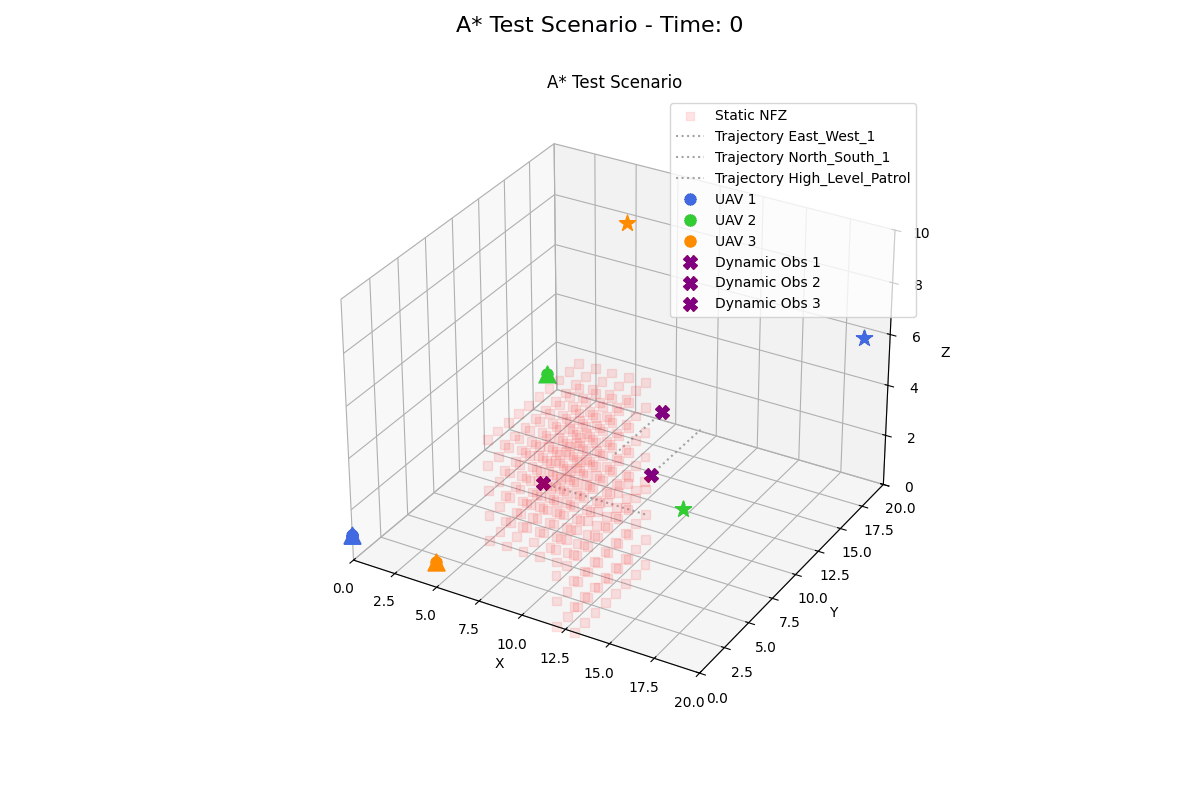

In [73]:
Image(filename="astar_test_scenario.gif")

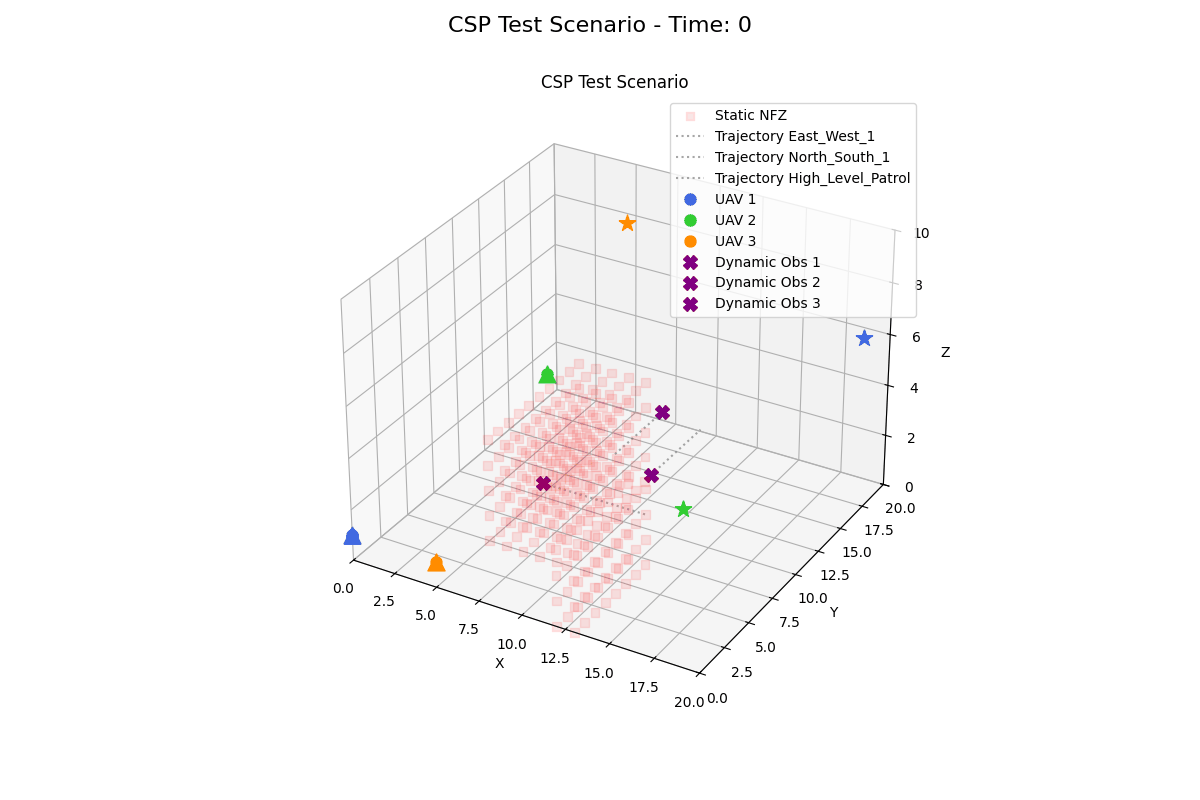

In [74]:
Image(filename="csp_test_scenario.gif")